In [3]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
df = pd.read_csv("StockPriceDataset.csv")
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-03,19.745001,19.775000,19.301071,19.320715,16.893808,392467600,AAPL
2,2014-01-06,19.194643,19.528570,19.057142,19.426071,16.985926,412610800,AAPL
3,2014-01-07,19.440001,19.498571,19.211430,19.287144,16.864458,317209200,AAPL
4,2014-01-08,19.243214,19.484285,19.238930,19.409286,16.971254,258529600,AAPL


In [7]:
print(df.columns)
print(df.isnull().sum())

df.ffill(inplace=True)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)

df.reset_index(drop=True, inplace=True)
df.head()


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker'],
      dtype='str')
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2014-01-02,19.845715,19.893929,19.715000,19.754642,17.273226,234684800,AAPL
1,2014-01-02,81.330002,81.360001,80.320000,80.540001,59.643745,6981700,PG
2,2014-01-02,19.940001,19.968000,19.701000,19.898500,19.898500,42756000,AMZN
3,2014-01-02,91.139999,91.730003,91.010002,91.029999,68.816696,5919600,JNJ
4,2014-01-02,176.949997,178.380005,176.360001,176.889999,145.740128,1982100,GS


In [8]:
from sklearn.preprocessing import MinMaxScaler

features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[features]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data[:5]  # Display first 5 rows of scaled data


array([[0.01375817, 0.01305253, 0.01380268, 0.01320417, 0.21991627],
       [0.16412326, 0.16237286, 0.16548203, 0.16164126, 0.00612321],
       [0.01398875, 0.01323247, 0.01376765, 0.01355547, 0.03971211],
       [0.18811445, 0.18756484, 0.19223646, 0.1872577 , 0.00512599],
       [0.39797016, 0.39806482, 0.40584642, 0.39692675, 0.00142902]])

In [9]:
# Number of previous days to use for prediction
look_back = 60

X = []
y = []

for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i])   # past 60 days
    y.append(scaled_data[i, 3])            # next day's 'Close' price (index 3)

X, y = np.array(X), np.array(y)

# Split into training and test sets (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((20080, 60, 5), (5020, 60, 5), (20080,), (5020,))

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Use only 'Open', 'High', 'Low', 'Volume' to predict 'Close'
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 1.4594120825287784
R2 Score: 0.9997923668086192


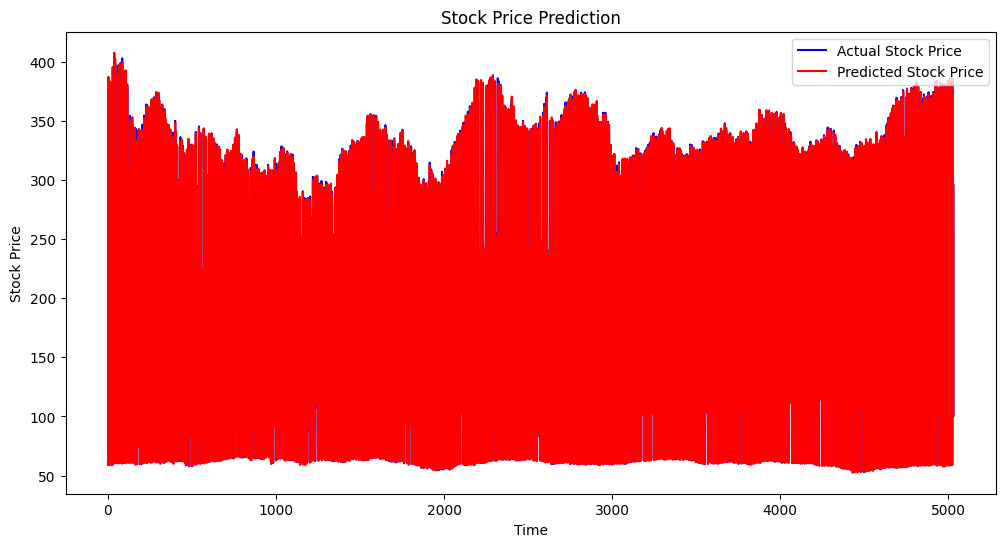

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, color='blue', label='Actual Stock Price')
plt.plot(y_pred, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [14]:
# Predict the next day's stock price using the last available row with column names
last_row = df[['Open', 'High', 'Low', 'Volume']].iloc[-1:]
next_day_pred = model.predict(last_row)
print("Predicted next day stock price:", next_day_pred[0])


Predicted next day stock price: 295.1437489572745


In [15]:
future_days = 5
predictions = []

# Start with the last row of your data
last_row = df[['Open', 'High', 'Low', 'Volume']].iloc[-1:].copy()

for i in range(future_days):
    next_pred = model.predict(last_row)[0]
    predictions.append(next_pred)
    
    # Prepare next input row
    # Here we assume Open, High, Low = previous day's predicted Close for simplicity
    last_row = pd.DataFrame({
        'Open': [next_pred],
        'High': [next_pred],
        'Low': [next_pred],
        'Volume': [last_row['Volume'].values[0]]  # keep same volume
    })

print("Next", future_days, "day predicted stock prices:", predictions)


Next 5 day predicted stock prices: [np.float64(295.1437489572745), np.float64(295.18319468001386), np.float64(295.2226451784662), np.float64(295.26210045320977), np.float64(295.30156050482276)]


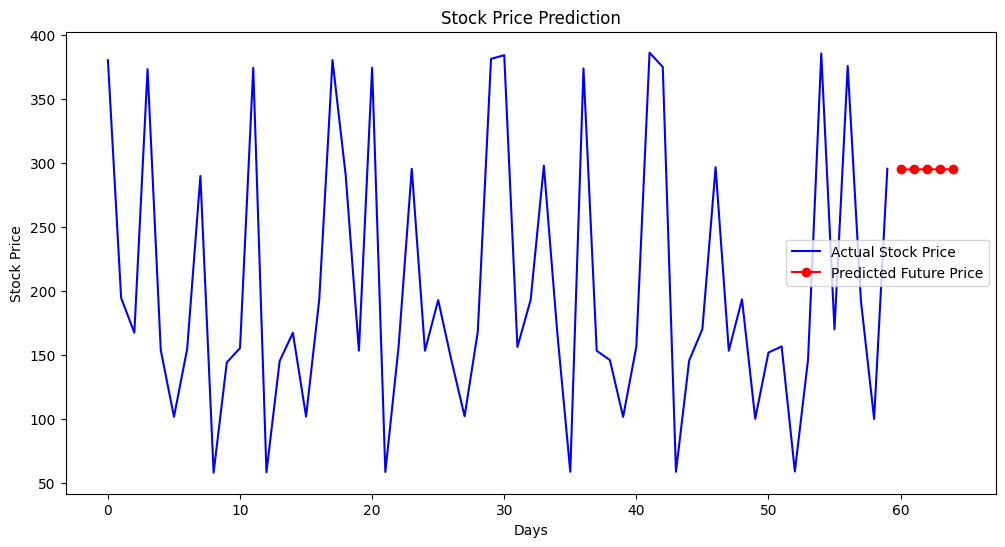

In [16]:
import matplotlib.pyplot as plt

# Plot actual stock prices (last 60 days for context)
plt.figure(figsize=(12,6))
plt.plot(df['Close'].iloc[-60:].values, color='blue', label='Actual Stock Price')

# Plot future predicted prices
future_index = range(len(df['Close'].iloc[-60:]), len(df['Close'].iloc[-60:]) + len(predictions))
plt.plot(future_index, predictions, color='red', marker='o', label='Predicted Future Price')

plt.title('Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.legend()
plt.show()
